In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
!pip install kneed
from kneed import KneeLocator
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import AgglomerativeClustering, KMeans

# Exploratory Data Analysis

In [67]:
# load dataset
url = "https://raw.githubusercontent.com/NathaliaMinoque/datasets/refs/heads/main/customer_classification_data.csv"
df = pd.read_csv(url)
df.head()

,Income,Age,Education,Credit_Score,Years_with_Bank,Transaction_Count,Balance,Loan_Approval_Amount,Credit_Card_Limit,Purchase_Frequency,Customer_Satisfaction,Online_Activity
0,66161.01279,57,Bachelor,503,1,41,1968.919899,2517.159284,5813.342700,0.975409,1,0.202693
1,78639.20248,60,High School,779,2,27,9797.056371,31501.758840,3991.007637,0.945920,2,0.549358
2,70207.25321,46,High School,519,14,95,7024.173403,16444.341580,6036.140567,0.272664,3,0.842993
3,65866.23872,42,High School,834,17,77,7992.359261,45233.592940,2691.192862,0.814385,4,0.119473
4,56774.10995,36,Bachelor,410,12,58,538.691042,48586.582480,10144.073090,0.346523,4,0.990168


In [68]:
df_cluster = df

In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Income                 500 non-null    float64
 1   Age                    500 non-null    int64  
 2   Education              500 non-null    object 
 3   Credit_Score           500 non-null    int64  
 4   Years_with_Bank        500 non-null    int64  
 5   Transaction_Count      500 non-null    int64  
 6   Balance                500 non-null    float64
 7   Loan_Approval_Amount   500 non-null    float64
 8   Credit_Card_Limit      500 non-null    float64
 9   Purchase_Frequency     500 non-null    float64
 10  Customer_Satisfaction  500 non-null    int64  
 11  Online_Activity        500 non-null    float64
dtypes: float64(6), int64(5), object(1)
memory usage: 47.0+ KB


In [70]:
print(df.shape)

(500, 12)


In [71]:
df.describe()

,Income,Age,Credit_Score,Years_with_Bank,Transaction_Count,Balance,Loan_Approval_Amount,Credit_Card_Limit,Purchase_Frequency,Customer_Satisfaction,Online_Activity
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,62244.823110,40.010000,564.992000,10.806000,48.486000,5062.825191,25395.518396,10609.972452,0.512753,2.564000,0.494516
std,21881.731581,13.051229,159.206663,5.151061,28.742339,2926.414765,14257.083307,5572.250431,0.282915,1.101058,0.294468
min,25352.160710,18.000000,300.000000,1.000000,1.000000,44.900440,1087.318821,1017.345471,0.000813,1.000000,0.001320
25%,43586.942127,29.000000,426.000000,7.000000,25.000000,2563.861164,13254.375542,5788.708258,0.272196,2.000000,0.239926
50%,61513.145375,39.000000,562.000000,11.000000,48.000000,4962.940262,25523.286385,10716.457885,0.531370,3.000000,0.485326
75%,79805.933200,51.000000,692.000000,15.000000,72.000000,7575.192218,38359.706343,15530.730127,0.763411,4.000000,0.759197
max,99913.525490,64.000000,849.000000,19.000000,99.000000,9984.440444,49971.895230,19968.520560,0.993942,4.000000,0.999897


In [72]:
# Check for NaN values
df.isna().sum()

,0
Income,0
Age,0
Education,0
Credit_Score,0
Years_with_Bank,0
Transaction_Count,0
Balance,0
Loan_Approval_Amount,0
Credit_Card_Limit,0
Purchase_Frequency,0


In [73]:
# Nilai tiap column

for col in df.columns:
    print(f"=== {col} ===")
    print(df[col].value_counts(dropna=False))
    print("\n")

=== Income ===
Income
62939.97879    1
66161.01279    1
78639.20248    1
70207.25321    1
56311.47811    1
              ..
97274.70704    1
91882.97506    1
57819.04084    1
73442.05848    1
56774.10995    1
Name: count, Length: 500, dtype: int64


=== Age ===
Age
29    17
47    17
56    17
34    17
33    16
35    15
21    14
55    14
25    14
44    13
41    13
54    12
48    12
37    12
23    12
30    12
39    12
42    11
24    11
52    11
19    11
40    10
51    10
46    10
36    10
22    10
28    10
18    10
62    10
57     9
32     9
50     9
31     8
26     8
63     8
43     8
61     8
27     8
38     8
20     7
45     7
60     7
59     7
49     7
58     7
53     6
64     6
Name: count, dtype: int64


=== Education ===
Education
High School    143
Bachelor       129
PhD            117
Master         111
Name: count, dtype: int64


=== Credit_Score ===
Credit_Score
567    6
410    5
455    4
519    4
677    3
      ..
755    1
365    1
808    1
753    1
830    1
Name: count, Lengt

## Encoding

In [74]:
new_df = df.copy()

In [75]:
# Education Encoding to make it numerical

edu_map = {'High School':1, 'Bachelor':2, 'Master':3, 'PhD':4}
new_df['Education'] = new_df['Education'].map(edu_map)

new_df.head()

,Income,Age,Education,Credit_Score,Years_with_Bank,Transaction_Count,Balance,Loan_Approval_Amount,Credit_Card_Limit,Purchase_Frequency,Customer_Satisfaction,Online_Activity
0,66161.01279,57,2,503,1,41,1968.919899,2517.159284,5813.342700,0.975409,1,0.202693
1,78639.20248,60,1,779,2,27,9797.056371,31501.758840,3991.007637,0.945920,2,0.549358
2,70207.25321,46,1,519,14,95,7024.173403,16444.341580,6036.140567,0.272664,3,0.842993
3,65866.23872,42,1,834,17,77,7992.359261,45233.592940,2691.192862,0.814385,4,0.119473
4,56774.10995,36,2,410,12,58,538.691042,48586.582480,10144.073090,0.346523,4,0.990168


In [76]:
# Pastikan semua fitur numerik yang akan dipakai
features = [
    'Income','Age','Education','Credit_Score','Years_with_Bank',
    'Transaction_Count','Balance','Loan_Approval_Amount','Credit_Card_Limit',
    'Purchase_Frequency','Customer_Satisfaction','Online_Activity'
]
X = new_df[features].copy()
X

,Income,Age,Education,Credit_Score,Years_with_Bank,Transaction_Count,Balance,Loan_Approval_Amount,Credit_Card_Limit,Purchase_Frequency,Customer_Satisfaction,Online_Activity
0,66161.01279,57,2,503,1,41,1968.919899,2517.159284,5813.342700,0.975409,1,0.202693
1,78639.20248,60,1,779,2,27,9797.056371,31501.758840,3991.007637,0.945920,2,0.549358
2,70207.25321,46,1,519,14,95,7024.173403,16444.341580,6036.140567,0.272664,3,0.842993
3,65866.23872,42,1,834,17,77,7992.359261,45233.592940,2691.192862,0.814385,4,0.119473
4,56774.10995,36,2,410,12,58,538.691042,48586.582480,10144.073090,0.346523,4,0.990168
...,...,...,...,...,...,...,...,...,...,...,...,...
495,45373.95757,30,4,336,14,71,1366.289637,10179.760810,10616.037340,0.157948,3,0.938356
496,59158.31121,50,2,362,9,4,3687.608472,1942.781623,2284.072698,0.840468,2,0.787210
497,55128.51515,38,3,753,7,31,9615.543105,38756.403270,8441.673159,0.811980,2,0.007766
498,43631.00988,61,3,742,6,14,1215.382326,11848.215650,19190.496120,0.666601,4,0.808457


## Visualization

### Barplot Customer Satisfaction

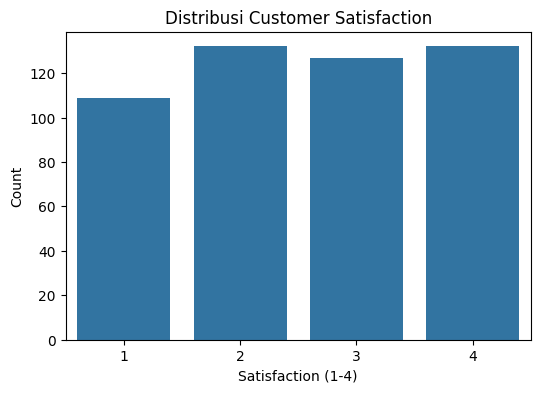

In [77]:
plt.figure(figsize=(6,4))
sns.countplot(x='Customer_Satisfaction', data=df)
plt.title('Distribusi Customer Satisfaction')
plt.xlabel('Satisfaction (1-4)')
plt.ylabel('Count')
plt.show()


Grafik batang Distribusi Customer Satisfaction menunjukkan tingkat kepuasan pelanggan pada skala 1 hingga 4. Terlihat bahwa sebagian besar pelanggan menilai kepuasan mereka pada level 2, 3, dan 4, dengan jumlah yang hampir seimbang, sementara level 1 (terendah) memiliki jumlah pelanggan paling sedikit. Pola ini mengindikasikan bahwa mayoritas pelanggan merasa cukup hingga sangat puas terhadap layanan bank, meskipun masih terdapat sebagian kecil pelanggan dengan tingkat kepuasan rendah. Temuan ini penting bagi pihak manajemen untuk mempertahankan kualitas layanan yang sudah memuaskan sebagian besar pelanggan, sekaligus melakukan evaluasi terhadap faktor-faktor yang menyebabkan sebagian kecil pelanggan memberikan nilai kepuasan rendah agar tingkat kepuasan secara keseluruhan dapat terus meningkat.

Sebagian besar pelanggan menilai kepuasan mereka pada level 2 hingga 4, dengan jumlah yang relatif seimbang. Hal ini menunjukkan bahwa mayoritas pelanggan merasa cukup hingga sangat puas terhadap layanan bank. Hanya sebagian kecil pelanggan yang memberikan nilai 1, yang dapat menjadi fokus evaluasi untuk peningkatan layanan. Secara umum tingkat kepuasan pelanggan tergolong positif, namun ada peluang untuk meningkatkan pengalaman pelanggan pada segmen yang kurang puas.

### Boxplot Balance untuk cek outlier

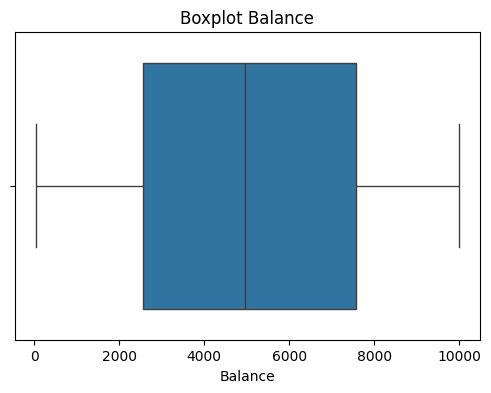

In [78]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Balance'])
plt.title('Boxplot Balance')
plt.show()

Boxplot Balance menunjukkan penyebaran saldo rekening pelanggan di bank. Dari visualisasi ini terlihat bahwa sebagian besar saldo pelanggan berada dalam rentang sekitar 2.000 hingga 8.000, dengan median mendekati 5.000–6.000. Tidak tampak adanya nilai ekstrem (outlier) yang signifikan, yang berarti distribusi saldo relatif merata dan stabil di antara pelanggan. Hal ini mengindikasikan bahwa kelompok pelanggan bank memiliki kondisi keuangan yang cukup seimbang, tanpa adanya dominasi pelanggan dengan saldo sangat tinggi atau sangat rendah. Temuan ini juga mendukung validitas data bahwa tidak ada anomali besar pada variabel Balance, sehingga variabel ini layak digunakan secara langsung dalam proses analisis dan pemodelan clustering.

Sebaran saldo pelanggan (Balance) relatif merata dan stabil, dengan median sekitar 5.000–6.000 dan tanpa adanya outlier signifikan. Hal ini menandakan bahwa mayoritas pelanggan memiliki saldo dalam kisaran menengah menunjukkan basis pelanggan yang homogen secara finansial, tanpa perbedaan ekstrem antara pelanggan dengan saldo tinggi dan rendah. Jika dikaitkan dengan skor kredit atau pendapatan, pelanggan dengan saldo lebih tinggi kemungkinan memiliki kestabilan finansial yang lebih baik.

### Scatter Income vs Credit_Score

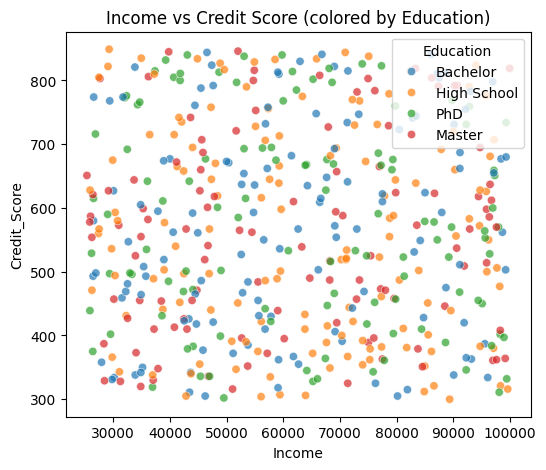

In [79]:
plt.figure(figsize=(6,5))
sns.scatterplot(x='Income', y='Credit_Score', hue='Education', data=df, alpha=0.7)
plt.title('Income vs Credit Score (colored by Education)')
plt.show()

Scatterplot Income vs Credit Score (colored by Education) memperlihatkan hubungan antara tingkat pendapatan pelanggan dengan skor kredit, dengan warna yang merepresentasikan jenjang pendidikan. Secara umum, data tampak tersebar merata tanpa pola linear yang jelas antara pendapatan dan skor kredit artinya, pendapatan tinggi tidak selalu berkorelasi langsung dengan skor kredit yang tinggi, dan sebaliknya. Namun, terdapat kecenderungan ringan bahwa pelanggan dengan pendidikan lebih tinggi (Master dan PhD) sedikit lebih sering berada pada area dengan income dan credit score di atas rata-rata, dibandingkan pelanggan dengan pendidikan High School. Hal ini dapat menunjukkan bahwa tingkat pendidikan berpotensi berkontribusi pada perilaku finansial yang lebih stabil atau manajemen kredit yang lebih baik. Meski demikian, variabilitas yang tinggi antarindividu menunjukkan bahwa faktor lain (seperti lama hubungan dengan bank atau frekuensi transaksi) juga berperan penting dalam menentukan skor kredit pelanggan.

Tidak terlihat korelasi yang sangat kuat antara pendapatan dan skor kredit, tetapi pelanggan dengan pendidikan lebih tinggi (Master dan PhD) cenderung memiliki income dan credit score lebih tinggi dibandingkan yang berpendidikan High School. Pendidikan tampaknya berperan dalam membentuk perilaku finansial pelanggan berpendidikan tinggi cenderung memiliki pendapatan lebih baik dan manajemen kredit yang lebih sehat. Ini membuka peluang bagi bank untuk menawarkan produk premium atau kredit dengan limit lebih tinggi kepada segmen ini.

# Data Scaling

In [80]:
scaler_std = StandardScaler()
scaler_mm = MinMaxScaler()

X_unscaled = X.copy()
X_standard = pd.DataFrame(scaler_std.fit_transform(X), columns=X.columns)
X_minmax = pd.DataFrame(scaler_mm.fit_transform(X), columns=X.columns)

# K-Means Clustering

In [81]:
from sklearn.cluster import KMeans

### Elbow Method Unscaled

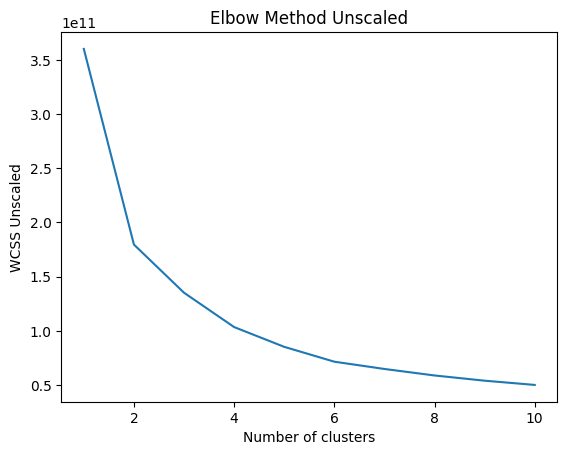

The optimal number of clusters is: 3


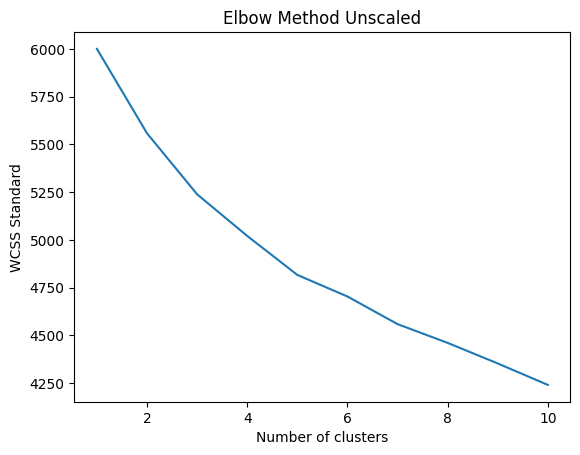

The optimal number of clusters is: 5


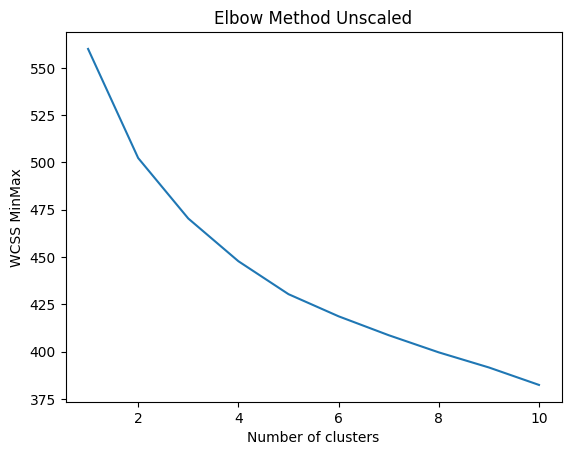

The optimal number of clusters is: 4


In [82]:
wcss_unscaled = []
wcss_standard = []
wcss_minmax = []

for i in range(1, 11):
    # Unscaled
    kmeans_unscaled = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=0)
    kmeans_unscaled.fit(X_unscaled)
    wcss_unscaled.append(kmeans_unscaled.inertia_)

    # StandardScaler
    kmeans_standard = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=0)
    kmeans_standard.fit(X_standard)
    wcss_standard.append(kmeans_standard.inertia_)

    # MinMaxScaler
    kmeans_minmax = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=0)
    kmeans_minmax.fit(X_minmax)
    wcss_minmax.append(kmeans_minmax.inertia_)

plt.plot(range(1, 11), wcss_unscaled)
plt.title('Elbow Method Unscaled')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS Unscaled')
plt.show()

clusters = range(1, 11)
knee_locator = KneeLocator(clusters, wcss_unscaled, curve="convex", direction="decreasing")
optimal_clusters_unscaled = knee_locator.knee
print(f"The optimal number of clusters is: {optimal_clusters_unscaled}")

plt.plot(range(1, 11), wcss_standard)
plt.title('Elbow Method Unscaled')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS Standard')
plt.show()

clusters = range(1, 11)
knee_locator = KneeLocator(clusters, wcss_standard, curve="convex", direction="decreasing")
optimal_clusters_standard = knee_locator.knee
print(f"The optimal number of clusters is: {optimal_clusters_standard}")

plt.plot(range(1, 11), wcss_minmax)
plt.title('Elbow Method Unscaled')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS MinMax')
plt.show()

clusters = range(1, 11)
knee_locator = KneeLocator(clusters, wcss_minmax, curve="convex", direction="decreasing")
optimal_clusters_minmax = knee_locator.knee
print(f"The optimal number of clusters is: {optimal_clusters_minmax}")

In [90]:
# Unscaled
kmeans_unscaled = KMeans(n_clusters=optimal_clusters_unscaled, init='k-means++', max_iter=300, n_init=10, random_state=0)
kmeans_unscaled.fit(X_unscaled)
wcss_unscaled.append(kmeans_unscaled.inertia_)

# StandardScaler
kmeans_standard = KMeans(n_clusters=optimal_clusters_standard, init='k-means++', max_iter=300, n_init=10, random_state=0)
kmeans_standard.fit(X_standard)
wcss_standard.append(kmeans_standard.inertia_)

# MinMaxScaler
kmeans_minmax = KMeans(n_clusters=optimal_clusters_minmax, init='k-means++', max_iter=300, n_init=10, random_state=0)
kmeans_minmax.fit(X_minmax)
wcss_minmax.append(kmeans_minmax.inertia_)

In [91]:
# Tambahkan cluster labels ke DataFrame asli
new_df['Cluster_Unscaled'] = kmeans_unscaled.labels_
new_df['Cluster_Standard'] = kmeans_standard.labels_
new_df['Cluster_MinMax'] = kmeans_minmax.labels_

# Cek hasil
new_df.head()


,Income,Age,Education,Credit_Score,Years_with_Bank,Transaction_Count,Balance,Loan_Approval_Amount,Credit_Card_Limit,Purchase_Frequency,Customer_Satisfaction,Online_Activity,Cluster_Unscaled,Cluster_Standard,Cluster_MinMax
0,66161.01279,57,2,503,1,41,1968.919899,2517.159284,5813.342700,0.975409,1,0.202693,0,1,3
1,78639.20248,60,1,779,2,27,9797.056371,31501.758840,3991.007637,0.945920,2,0.549358,1,0,3
2,70207.25321,46,1,519,14,95,7024.173403,16444.341580,6036.140567,0.272664,3,0.842993,1,2,1
3,65866.23872,42,1,834,17,77,7992.359261,45233.592940,2691.192862,0.814385,4,0.119473,2,0,1
4,56774.10995,36,2,410,12,58,538.691042,48586.582480,10144.073090,0.346523,4,0.990168,2,2,0


In [92]:
from sklearn.metrics import silhouette_score

sil_unscaled = silhouette_score(X_unscaled, new_df['Cluster_Unscaled'])
sil_standard = silhouette_score(X_standard, new_df['Cluster_Standard'])
sil_minmax = silhouette_score(X_minmax, new_df['Cluster_MinMax'])

print(f"Silhouette Score (Unscaled): {sil_unscaled:.3f}")
print(f"Silhouette Score (Standard Scaled): {sil_standard:.3f}")
print(f"Silhouette Score (MinMax Scaled): {sil_minmax:.3f}")

Silhouette Score (Unscaled): 0.362
Silhouette Score (Standard Scaled): 0.070
Silhouette Score (MinMax Scaled): 0.078


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


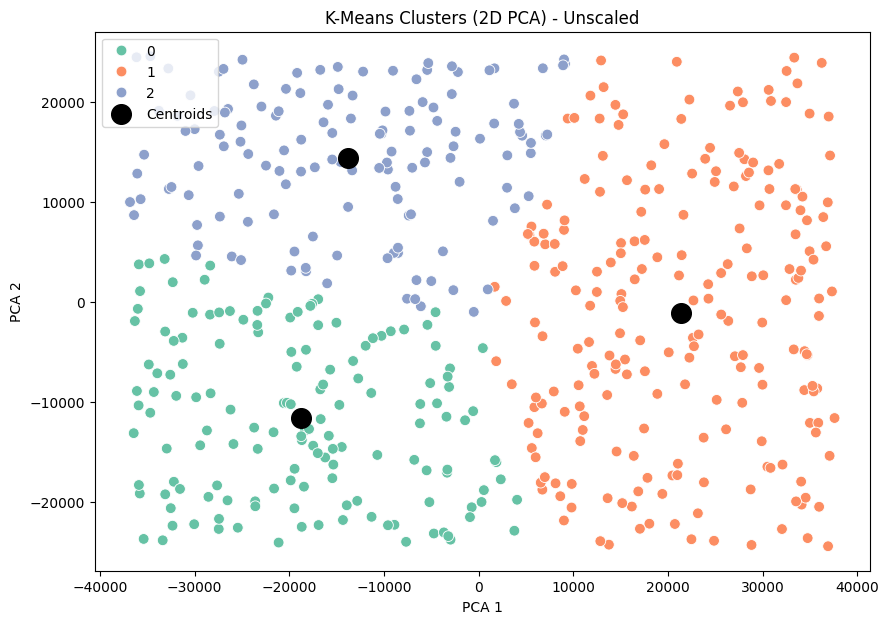

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


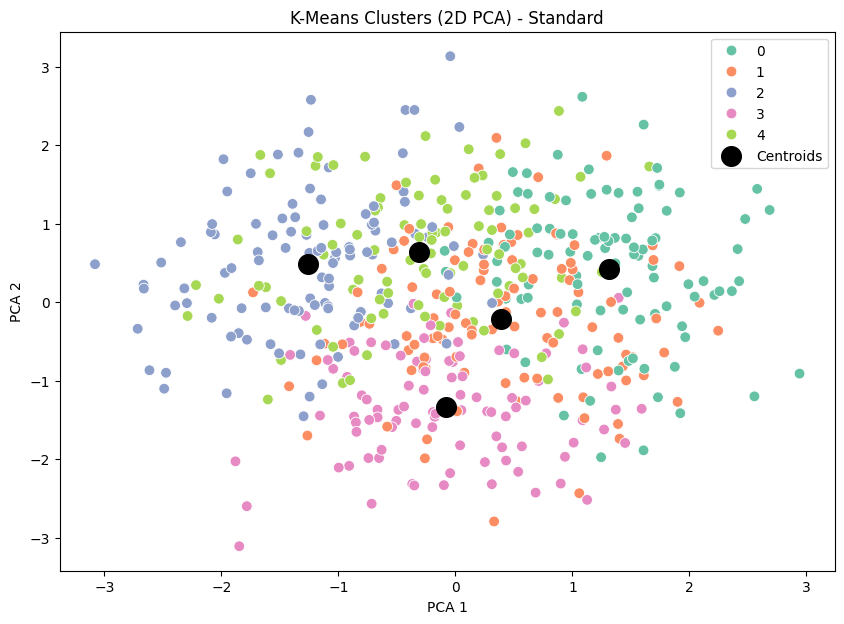

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


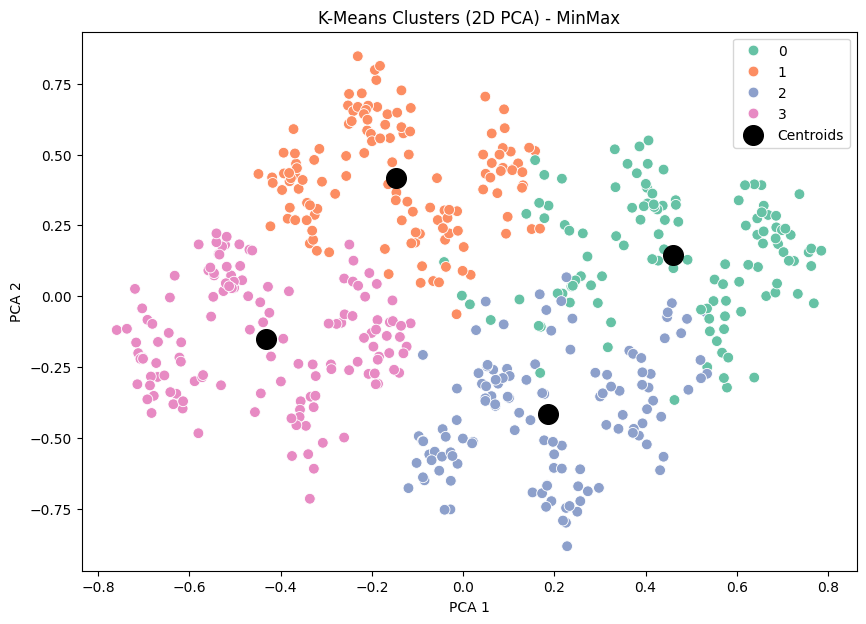

In [93]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# List versi untuk loop
versions = {
    "Unscaled": (X_unscaled, kmeans_unscaled),
    "Standard": (X_standard, kmeans_standard),
    "MinMax": (X_minmax, kmeans_minmax)
}

for name, (X_data, kmeans_model) in versions.items():
    # PCA 2D
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_data)

    # Centroids di PCA space
    centroids_pca = pca.transform(kmeans_model.cluster_centers_)

    # Plot
    plt.figure(figsize=(10,7))
    sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=kmeans_model.labels_, palette='Set2', s=60)
    plt.scatter(centroids_pca[:,0], centroids_pca[:,1], s=200, c='black', label='Centroids')
    plt.title(f'K-Means Clusters (2D PCA) - {name}')
    plt.xlabel('PCA 1')
    plt.ylabel('PCA 2')
    plt.legend()
    plt.show()


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


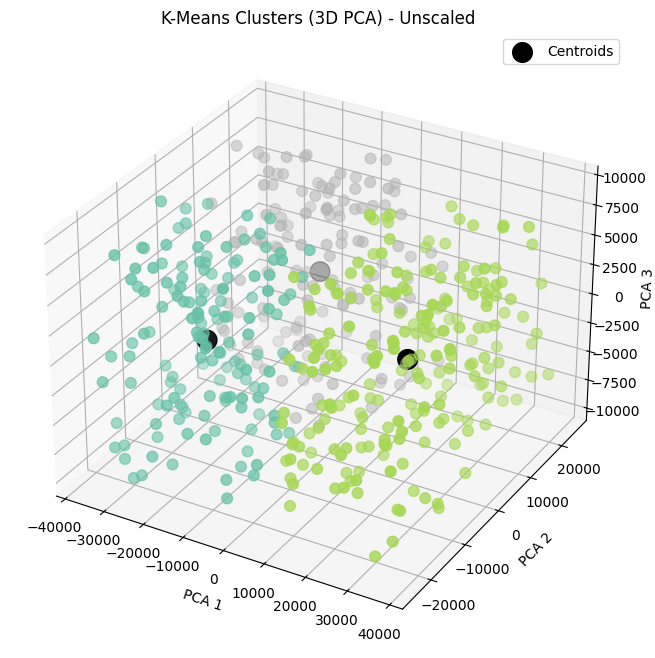

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


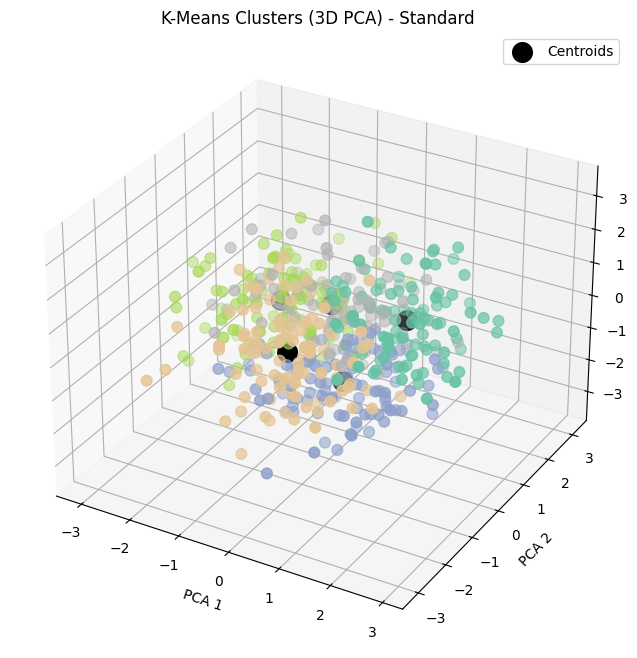

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


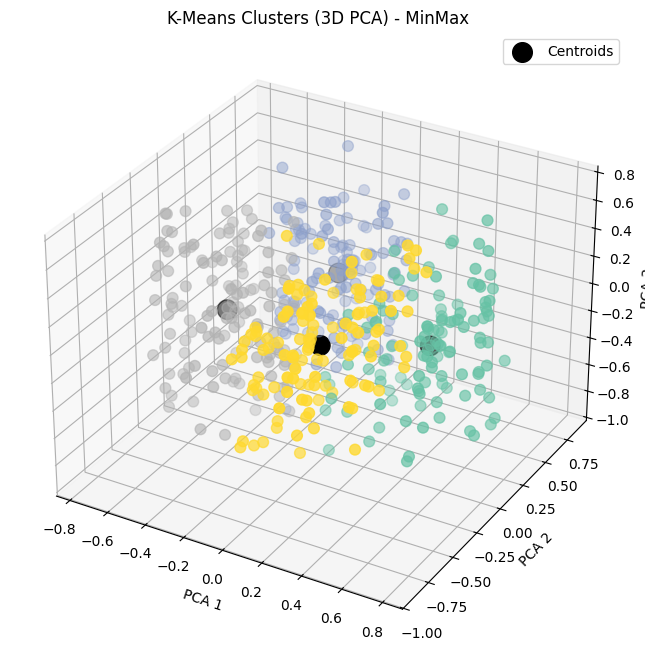

In [94]:
from mpl_toolkits.mplot3d import Axes3D

for name, (X_data, kmeans_model) in versions.items():
    # PCA 3D
    pca3 = PCA(n_components=3)
    X_pca3 = pca3.fit_transform(X_data)

    # Centroids di PCA 3D
    centroids_pca3 = pca3.transform(kmeans_model.cluster_centers_)

    # Plot
    fig = plt.figure(figsize=(10,8))
    ax = fig.add_subplot(111, projection='3d')
    scatter = ax.scatter(X_pca3[:,0], X_pca3[:,1], X_pca3[:,2], c=kmeans_model.labels_, cmap='Set2', s=60)
    ax.scatter(centroids_pca3[:,0], centroids_pca3[:,1], centroids_pca3[:,2], s=200, c='black', label='Centroids')
    ax.set_title(f'K-Means Clusters (3D PCA) - {name}')
    ax.set_xlabel('PCA 1')
    ax.set_ylabel('PCA 2')
    ax.set_zlabel('PCA 3')
    legend = ax.legend()
    plt.show()


## Summary

In [95]:
new_df['Cluster_Unscaled'] = kmeans_unscaled.labels_

cluster_summary_unscaled = new_df.groupby('Cluster_Unscaled').agg({
    'Age': ['mean', 'median', 'min', 'max'],
    'Income': ['mean', 'median', 'min', 'max'],
    'Education': ['mean', 'median', 'min', 'max'],
    'Credit_Score': ['mean', 'median', 'min', 'max'],
    'Years_with_Bank': ['mean', 'median', 'min', 'max'],
    'Transaction_Count': ['mean', 'median', 'min', 'max'],
    'Balance': ['mean', 'median', 'min', 'max'],
    'Loan_Approval_Amount': ['mean', 'median', 'min', 'max'],
    'Credit_Card_Limit': ['mean', 'median', 'min', 'max'],
    'Purchase_Frequency': ['mean', 'median', 'min', 'max'],
    'Customer_Satisfaction': ['mean', 'median', 'min', 'max'],
    'Online_Activity': ['mean', 'median', 'min', 'max']
})

cluster_summary_unscaled


Age                       Income                \
                       mean median min max          mean        median   
Cluster_Unscaled                                                         
0                 40.537415   40.0  18  63  43512.790209  43631.009880   
1                 40.152074   40.0  18  64  83605.930546  83539.688220   
2                 39.213235   37.5  18  64  48408.415188  48752.932385   

                                           Education         ...  \
                          min          max      mean median  ...   
Cluster_Unscaled                                             ...   
0                 25878.55631  66414.43524  2.367347    2.0  ...   
1                 63912.63616  99913.52549  2.400922    2.0  ...   
2                 25352.16071  71322.66228  2.448529    2.0  ...   

                 Purchase_Frequency           Customer_Satisfaction         \
                                min       max                  mean median   
Cluster_Unscaled                                                             
0                          0.007371  0.986368              2.476190    2.0   
1                          0.000813  0.993942              2.617512    3.0   
2                          0.001914  0.991562              2.573529    2.0   

                         Online_Activity                                
                 min max            mean    median       min       max  
Cluster_Unscaled                                                        
0                  1   4        0.510041  0.538979  0.001432  0.999897  
1                  1   4        0.463503  0.406844  0.001320  0.996199  
2                  1   4        0.527221  0.515725  0.007766  0.999120  

[3 rows x 48 columns]

In [96]:
new_df['Cluster_Standard'] = kmeans_standard.labels_

cluster_summary_standard = new_df.groupby('Cluster_Standard').agg({
    'Age': ['mean', 'median', 'min', 'max'],
    'Income': ['mean', 'median', 'min', 'max'],
    'Education': ['mean', 'median', 'min', 'max'],
    'Credit_Score': ['mean', 'median', 'min', 'max'],
    'Years_with_Bank': ['mean', 'median', 'min', 'max'],
    'Transaction_Count': ['mean', 'median', 'min', 'max'],
    'Balance': ['mean', 'median', 'min', 'max'],
    'Loan_Approval_Amount': ['mean', 'median', 'min', 'max'],
    'Credit_Card_Limit': ['mean', 'median', 'min', 'max'],
    'Purchase_Frequency': ['mean', 'median', 'min', 'max'],
    'Customer_Satisfaction': ['mean', 'median', 'min', 'max'],
    'Online_Activity': ['mean', 'median', 'min', 'max']
})

cluster_summary_standard


Age                       Income                \
                       mean median min max          mean        median   
Cluster_Standard                                                         
0                 44.275510   45.0  18  64  72548.400801  75995.593725   
1                 39.190476   39.0  18  64  61353.500126  59027.263340   
2                 41.295238   41.0  18  64  48488.924951  44904.211820   
3                 31.000000   29.0  18  63  71112.460833  72849.327880   
4                 44.436170   46.5  18  63  58619.068954  55608.902220   

                                           Education         ...  \
                          min          max      mean median  ...   
Cluster_Standard                                             ...   
0                 26232.22222  99128.03785  1.846939    2.0  ...   
1                 26516.37981  99580.05922  2.095238    2.0  ...   
2                 25857.05940  98257.08161  2.476190    2.0  ...   
3                 25352.16071  99913.52549  3.071429    3.0  ...   
4                 25992.76433  98234.45988  2.553191    3.0  ...   

                 Purchase_Frequency           Customer_Satisfaction         \
                                min       max                  mean median   
Cluster_Standard                                                             
0                          0.011290  0.991089              2.704082    3.0   
1                          0.000813  0.986368              2.609524    3.0   
2                          0.001914  0.858434              2.247619    2.0   
3                          0.019552  0.985055              1.836735    2.0   
4                          0.025873  0.993942              3.478723    4.0   

                         Online_Activity                                
                 min max            mean    median       min       max  
Cluster_Standard                                                        
0                  1   4        0.245601  0.219505  0.003092  0.727256  
1                  1   4        0.370171  0.304790  0.001432  0.990125  
2                  1   4        0.644028  0.713240  0.041645  0.990912  
3                  1   4        0.518610  0.546802  0.001320  0.994756  
4                  1   4        0.700794  0.742235  0.008469  0.999897  

[5 rows x 48 columns]

In [97]:
new_df['Cluster_MinMax'] = kmeans_minmax.labels_

cluster_summary_minmax = new_df.groupby('Cluster_MinMax').agg({
    'Age': ['mean', 'median', 'min', 'max'],
    'Income': ['mean', 'median', 'min', 'max'],
    'Education': ['mean', 'median', 'min', 'max'],
    'Credit_Score': ['mean', 'median', 'min', 'max'],
    'Years_with_Bank': ['mean', 'median', 'min', 'max'],
    'Transaction_Count': ['mean', 'median', 'min', 'max'],
    'Balance': ['mean', 'median', 'min', 'max'],
    'Loan_Approval_Amount': ['mean', 'median', 'min', 'max'],
    'Credit_Card_Limit': ['mean', 'median', 'min', 'max'],
    'Purchase_Frequency': ['mean', 'median', 'min', 'max'],
    'Customer_Satisfaction': ['mean', 'median', 'min', 'max'],
    'Online_Activity': ['mean', 'median', 'min', 'max']
})

cluster_summary_minmax


Age                       Income               \
                     mean median min max          mean       median   
Cluster_MinMax                                                        
0               43.008547   42.0  18  64  59013.065254  56789.12864   
1               40.546875   42.0  18  62  65760.734829  67217.60276   
2               36.834711   35.0  18  64  63532.871100  62304.35241   
3               39.746269   37.0  18  64  60545.010888  58710.51480   

                                         Education         ...  \
                        min          max      mean median  ...   
Cluster_MinMax                                             ...   
0               25992.76433  99400.84326  3.384615    3.0  ...   
1               26232.22222  98637.20424  1.460938    1.0  ...   
2               25352.16071  99913.52549  3.504132    4.0  ...   
3               25902.71672  99580.05922  1.455224    1.0  ...   

               Purchase_Frequency           Customer_Satisfaction             \
                              min       max                  mean median min   
Cluster_MinMax                                                                 
0                        0.001914  0.979407              3.564103    4.0   2   
1                        0.000813  0.991562              3.476562    3.0   3   
2                        0.003571  0.993942              1.743802    2.0   1   
3                        0.011290  0.988192              1.559701    2.0   1   

                   Online_Activity                                
               max            mean    median       min       max  
Cluster_MinMax                                                    
0                4        0.510753  0.496006  0.009964  0.996199  
1                4        0.438657  0.388672  0.001432  0.999897  
2                3        0.521248  0.540570  0.002706  0.981656  
3                3        0.509560  0.476962  0.001320  0.999120  

[4 rows x 48 columns]

## Summarize & Discuss Which Model is Better



a. Clarity of Cluster Separation

- Unscaled: Ada cluster dengan nilai Income dan Age yang tinggi dan rendah bercampur. Cluster overlap cukup banyak → kurang jelas pemisahan.
- Standard Scaled: Cluster lebih seimbang karena semua fitur memiliki kontribusi yang setara. Pemisahan antar cluster lebih jelas, terutama untuk fitur yang berbeda skala (Income vs Age vs Purchase_Frequency).
- MinMax Scaled: Mirip Standard, tapi beberapa cluster ekstrem terlihat lebih jelas karena skala semua fitur antara 0–1. Cluster menonjolkan perbedaan relatif antar fitur.

Kesimpulan:
- Scaled data (Standard atau MinMax) lebih baik karena fitur dengan skala besar (Income, Balance) tidak mendominasi clustering. Scaling membantu K-Means bekerja lebih adil di semua fitur → cluster lebih interpretable.

b. Kenapa Scaling Mempengaruhi Hasil K-Means

- K-Means menggunakan jarak Euclidean, sehingga fitur dengan range besar akan mendominasi jarak akibatnya cluster bias ke fitur tersebut.
- Scaling (Standard atau MinMax) membuat semua fitur berkontribusi proporsional akibatnya cluster yang terbentuk lebih representatif.

## Interpretasi Karakteristik Cluster

### Unscaled

| Cluster | Karakteristik                                                                                                                                  |
| ------- | ---------------------------------------------------------------------------------------------------------------------------------------------- |
| 0       | Age 40, Income rendah (~43k), Education ~2, Purchase_Frequency rendah, Online_Activity tinggi → “Young, digitally active, low–medium income.” |
| 1       | Age 40, Income tinggi (~83k), Education ~2, Customer_Satisfaction lebih tinggi → “High-income, loyal, slightly older.”                        |
| 2       | Age 39, Income sedang (~48k), Education ~2, Purchase_Frequency sedang → “Medium income, moderate engagement.”                                 |


### Standard

| Cluster | Karakteristik                                                                                          |
| ------- | ------------------------------------------------------------------------------------------------------ |
| 0       | Age 44, Income tinggi (~72k), Education ~1.85 → “Older, high-income customers with medium education.” |
| 1       | Age 39, Income ~61k, Education ~2 → “Middle-aged, medium-high income, moderate activity.”             |
| 2       | Age 41, Income rendah (~48k), Education ~2 → “Middle-aged, lower income, medium activity.”            |
| 3       | Age 31, Income tinggi (~71k), Education ~3 → “Younger, higher-income, higher education.”              |
| 4       | Age 44, Income ~58k, Education ~3 → “Older, medium income, high education.”                           |

### MinMax

| Cluster | Karakteristik                                                                                   |
| ------- | ----------------------------------------------------------------------------------------------- |
| 0       | Age 43, Income ~59k, Education ~3 → “Older, medium-high income, high education.”               |
| 1       | Age 40, Income ~65k, Education ~1.5 → “Middle-aged, high income, medium-low education.”        |
| 2       | Age 36, Income ~63k, Education ~4 → “Younger, high income, highest education.”                 |
| 3       | Age 39, Income ~60k, Education ~1.5 → “Middle-aged, medium-high income, low-medium education.” |


## Managerial Recommendations

1. Targeting Produk & Marketing
- Cluster dengan Income tinggi + Education tinggi → bisa ditawarkan produk premium, loyalty program, investasi atau layanan eksklusif.
- Cluster Younger + Digital Active → promosikan digital campaigns, mobile apps, gamified engagement, cashback offers.
- Cluster Medium income + medium activity → bundle produk terjangkau, edukasi produk, referral program.

2. Prioritas Growth atau Retention
- Retention: Prioritaskan high-income loyal cluster karena mereka memberikan revenue stabil.
- Growth: Fokus young, digitally active cluster → potensial untuk upselling atau meningkatkan engagement digital.

3. Strategi Lanjutan
- Gunakan personalized marketing berdasarkan Education dan Online_Activity.
- Segmentasi lebih lanjut bisa dipadukan dengan Credit_Score atau Loan_Approval_Amount untuk produk finansial.
- Scaling data disarankan untuk analisis lanjutan agar cluster lebih jelas dan strategi lebih tepat sasaran.